In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

# STUDENT TASK 1: Replace the boilerplate text with a custom paragraph corpus.
# Using a short paragraph about AI so the models have something interesting to learn from.
custom_corpus = """
Artificial intelligence is evolving at an unprecedented rate. We are teaching machines
to understand the complexities of human language. Deep learning architectures like
recurrent neural networks allow systems to retain memory of past inputs. However,
advanced models such as long short term memory and gated recurrent units solve the
vanishing gradient problem. This enables machines to generate highly coherent and
contextually accurate text sequences. The future of natural language processing
holds endless possibilities for human computer interaction.
"""

# Clean the text: remove newlines, make it lowercase, and split into sentences
sentences = custom_corpus.replace('\n', ' ').strip().lower().split('. ')

# Initialize Tokenizer to map our words to integers
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

# Adding 1 because indexing starts at 0, but 0 is reserved for padding
total_words = len(tokenizer.word_index) + 1

print(f"Total unique words found in corpus: {total_words}")

Total unique words found in corpus: 66


In [2]:
input_sequences = []

# Reframe the text into progressive sliding-window combinations (n-grams)
for line in sentences:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

# Find the longest sequence so we can pad everything else to match its length
max_sequence_len = max([len(x) for x in input_sequences])

# Pad sequences with zeros at the beginning ('pre') so all vectors are the same size
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

# Split into features (X) and target labels (y)
# X gets everything except the last word. y gets the last word.
X = input_sequences[:, :-1]
labels = input_sequences[:, -1]

# Convert the labels to one-hot encoded arrays for categorical cross-entropy loss
y = tf.keras.utils.to_categorical(labels, num_classes=total_words)

print(f"Features (X) shape: {X.shape}")
print(f"Labels (y) shape: {y.shape}")

Features (X) shape: (71, 17)
Labels (y) shape: (71, 66)


In [3]:
# STUDENT TASK 2: Upscale embedding dimensions
embedding_dim = 64

# STUDENT TASK 4: Widen hidden layers (64 -> 128)
hidden_units = 128

# Helper function to build our 3 distinct models
def build_model(architecture_type):
    model = tf.keras.models.Sequential()

    # Shared embedding layer
    model.add(tf.keras.layers.Embedding(total_words, embedding_dim, input_length=max_sequence_len-1))

    # Add the specific recurrent layer based on what we ask for
    if architecture_type == 'RNN':
        model.add(tf.keras.layers.SimpleRNN(hidden_units))
    elif architecture_type == 'LSTM':
        model.add(tf.keras.layers.LSTM(hidden_units))
    elif architecture_type == 'GRU':
        model.add(tf.keras.layers.GRU(hidden_units))

    # Output layer with softmax to give us probabilities for the next word
    model.add(tf.keras.layers.Dense(total_words, activation='softmax'))

    # Compile using the exact same optimizer config for a fair comparison
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Build all three variations
rnn_model = build_model('RNN')
lstm_model = build_model('LSTM')
gru_model = build_model('GRU')

print("All three models (RNN, LSTM, GRU) are built and compiled!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


All three models (RNN, LSTM, GRU) are built and compiled!


In [4]:
# STUDENT TASK 3: Expand training to 200 epochs
epochs_count = 200

# Note: We are using verbose=0 to hide the massive wall of text during training.
# It will take a minute or two to finish running.
print(f"Starting training for {epochs_count} epochs... Please wait.")

print("-> Training Vanilla RNN...")
rnn_history = rnn_model.fit(X, y, epochs=epochs_count, verbose=0)

print("-> Training LSTM...")
lstm_history = lstm_model.fit(X, y, epochs=epochs_count, verbose=0)

print("-> Training GRU...")
gru_history = gru_model.fit(X, y, epochs=epochs_count, verbose=0)

print("Training finished successfully for all models!")

Starting training for 200 epochs... Please wait.
-> Training Vanilla RNN...
-> Training LSTM...
-> Training GRU...
Training finished successfully for all models!


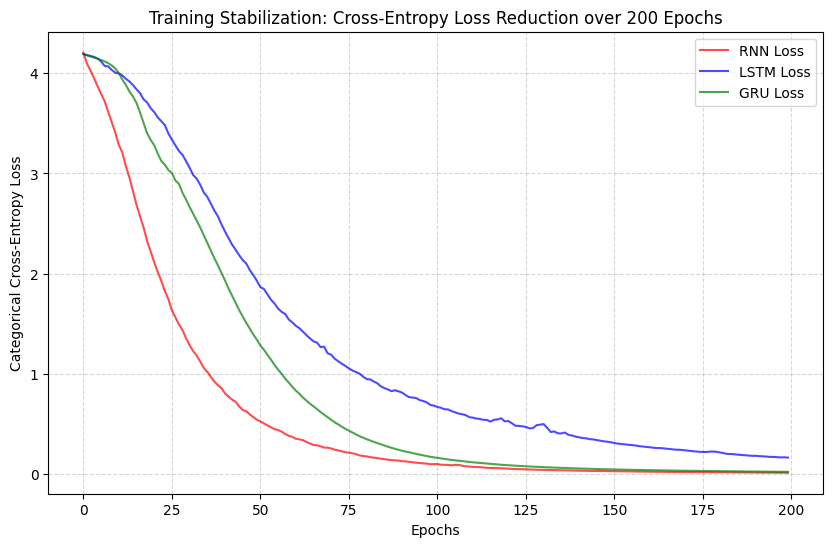

In [5]:
# MENTOR CHECKLIST 1: A complete training curve line graph illustrating cross-entropy loss reduction
plt.figure(figsize=(10, 6))

# Map optimization trajectories to evaluate training stabilization speeds
plt.plot(rnn_history.history['loss'], label='RNN Loss', color='red', alpha=0.7)
plt.plot(lstm_history.history['loss'], label='LSTM Loss', color='blue', alpha=0.7)
plt.plot(gru_history.history['loss'], label='GRU Loss', color='green', alpha=0.7)

plt.title('Training Stabilization: Cross-Entropy Loss Reduction over 200 Epochs')
plt.xlabel('Epochs')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [6]:
def generate_text(seed_phrase, num_words_to_generate, model, max_length):
    generated_output = seed_phrase

    for _ in range(num_words_to_generate):
        # Convert our current text into numbers and pad it
        token_list = tokenizer.texts_to_sequences([generated_output])[0]
        token_list = pad_sequences([token_list], maxlen=max_length-1, padding='pre')

        # Predict the probabilities for the next word
        predicted_probs = model.predict(token_list, verbose=0)

        # INSTRUCTION 6: Program the internal selection logic using np.argmax
        predicted_idx = np.argmax(predicted_probs, axis=-1)[0]

        # Find the word that corresponds to this index
        next_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_idx:
                next_word = word
                break

        generated_output += " " + next_word

    return generated_output

# MENTOR CHECKLIST 2: Cleanly produce text from a shared seed phrase across all 3 models
shared_seed = "Deep learning architectures"

# STUDENT TASK 5: Adjust output to return exactly 10 words per generation prompt
words_to_generate = 10

print("===========================================")
print("         TEXT GENERATION RESULTS           ")
print("===========================================\n")
print(f"Starting Seed Phrase: '{shared_seed}'\n")

print("1. Vanilla RNN:")
print(generate_text(shared_seed, words_to_generate, rnn_model, max_sequence_len))

print("\n2. LSTM:")
print(generate_text(shared_seed, words_to_generate, lstm_model, max_sequence_len))

print("\n3. GRU:")
print(generate_text(shared_seed, words_to_generate, gru_model, max_sequence_len))

         TEXT GENERATION RESULTS           

Starting Seed Phrase: 'Deep learning architectures'

1. Vanilla RNN:
Deep learning architectures like recurrent neural networks allow systems to retain memory of

2. LSTM:
Deep learning architectures like recurrent neural networks allow systems to retain memory of

3. GRU:
Deep learning architectures like recurrent neural networks allow systems to retain memory of
